# Обучение с учителем
## Классификация и оценка качества модели
В данном примере загружается всё тот же датасет, приводится пример классификации и анализируется качество полученных моделей

## Подготовка датасета
Всё как в прошлый раз

### Подключение библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

### Датасет
Загрузим и обработаем.

In [3]:
df = pd.read_csv('possum.csv')
df=df.drop(['case'], axis=1)
df=df[(df['age']>0)&(df['footlgth']>0)]
sexes = {'m':0, 'f':1}
pops = {'Vic':0, 'other':1}
df=df.replace(sexes)
df=df.replace(pops)

C:\Users\valko\AppData\Local\Temp\ipykernel_4712\1429939591.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(sexes)
C:\Users\valko\AppData\Local\Temp\ipykernel_4712\1429939591.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(pops)


In [4]:
df_lin_reg_data=df.drop(['taill','totlngth','skullw','footlgth'], axis=1)
df_lin_reg_target=df['taill']

Для логистической регрессии нужны немного другие данные

In [5]:
df_log_reg_data=df.drop(['sex'], axis=1)
df_log_reg_target=df['sex']

И на будущее для классификации по возрастам

In [6]:
df_pol_reg_data=df.drop(['age'], axis=1)
df_pol_reg_target=df['age']

## Логистическая регрессия
Определим пол по параметрами опоссума
### Сначала делаем выборки
Тут всё как обычно

In [7]:
data_train_log, data_test_log, target_train_log, target_test_log = train_test_split(
df_log_reg_data, df_log_reg_target,
test_size=0.3, random_state=12
)

### Теперь обучение

In [8]:
logistic_regression = LogisticRegression(solver='liblinear')
model_log = logistic_regression.fit(data_train_log, target_train_log)
predicted_log = model_log.predict(data_test_log)

График тут не построить, так что просто выведем сводную таблицу

In [9]:
results_table = pd.DataFrame(list(zip(predicted_log, target_test_log)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)

    Предсказано  На самом деле
0             1              0
1             0              1
2             0              0
3             0              0
4             0              0
5             1              1
6             0              0
7             0              0
8             1              0
9             1              1
10            0              0
11            1              1
12            0              1
13            1              1
14            1              1
15            0              0
16            0              1
17            1              0
18            0              0
19            0              1
20            0              1
21            0              0
22            0              1
23            0              0
24            1              1
25            0              1
26            1              1
27            0              0
28            0              1
29            0              0
30            1              1


Определим точность

In [10]:
print(model_log.score(data_test_log, target_test_log))

0.6451612903225806


И построим матрицу несоответствий

[]

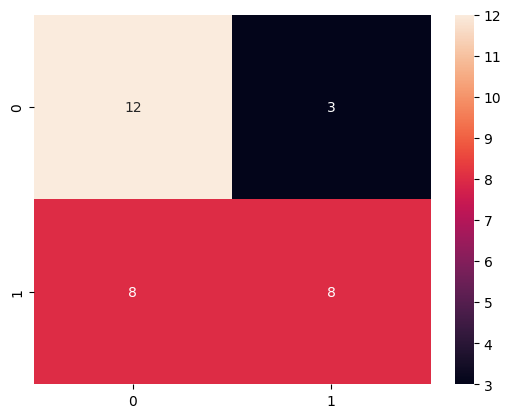

In [11]:
confusion_scores = confusion_matrix(target_test_log, predicted_log)
confusion_df = pd.DataFrame(confusion_scores, columns=np.sort(target_test_log.unique()),
index=np.sort(target_test_log.unique()))
sns.heatmap(confusion_df, annot=True).plot()

Довольно неплохо, посмотрим все характеристики

In [12]:
print('Точность:')
print(metrics.accuracy_score( target_test_log, predicted_log))
print('ROC AUC:')
print(metrics.roc_auc_score( target_test_log, predicted_log))
print('F1 - мера:')
print(metrics.f1_score( target_test_log, predicted_log))

Точность:
0.6451612903225806
ROC AUC:
0.6500000000000001
F1 - мера:
0.5925925925925926


## Классификация
Будем определять возраст опоссума - каждому классу соответсвует свой возраст
### Сначала выборки


In [13]:
data_train_pol, data_test_pol, target_train_pol, target_test_pol = train_test_split(
df_pol_reg_data, df_pol_reg_target,
test_size=0.3, random_state=12
)

### Теперь классифицируем
Используем тот же класс, но жругой метод, подходящий для многоклассовой классификации

In [14]:
logistic_regression_pol = LogisticRegression(solver='newton-cg')


In [15]:
model_pol_cl=logistic_regression_pol.fit(data_train_pol,target_train_pol)
predicted_pol = model_pol_cl.predict(data_test_pol)

In [16]:
results_table = pd.DataFrame(list(zip(predicted_pol, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)

    Предсказано  На самом деле
0           3.0            2.0
1           4.0            2.0
2           3.0            3.0
3           5.0            5.0
4           1.0            1.0
5           3.0            4.0
6           4.0            7.0
7           3.0            4.0
8           7.0            3.0
9           3.0            5.0
10          3.0            5.0
11          3.0            9.0
12          1.0            3.0
13          2.0            6.0
14          2.0            6.0
15          3.0            6.0
16          4.0            3.0
17          5.0            3.0
18          2.0            3.0
19          8.0            1.0
20          3.0            2.0
21          6.0            3.0
22          3.0            2.0
23          6.0            2.0
24          7.0            4.0
25          6.0            3.0
26          4.0            5.0
27          3.0            2.0
28          1.0            2.0
29          7.0            4.0
30          1.0            3.0


Посмотрим точность

In [17]:
print(model_pol_cl.score(data_test_pol, target_test_pol))

0.0967741935483871


Точность отсутствует... Почему? Просто некоторых опоссумов очень мало в датасете, скажем восьмилетний всего один...
Что делать?

Модернизируем датасет - пусть опоссумы в возрасте 1-2 будут первый класс, 3-5 - второй, а 6-9 - третий

In [18]:
ages = {1:0, 2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:2}
dfage=df.replace(ages)

In [19]:
df_pol_reg_data=dfage.drop(['age'], axis=1)
df_pol_reg_target=dfage['age']

Попробуем снова,указав дополнительный параметр чтобы в каждой выборке были все классы (раньше это было невозможно

In [20]:
data_train_pol, data_test_pol, target_train_pol, target_test_pol = train_test_split(
df_pol_reg_data, df_pol_reg_target,stratify=df_pol_reg_target,
test_size=0.3, random_state=12
)

In [21]:
model_pol_cl=logistic_regression_pol.fit(data_train_pol,target_train_pol)
predicted_pol = model_pol_cl.predict(data_test_pol)

In [22]:
results_table = pd.DataFrame(list(zip(predicted_pol, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)
print(model_pol_cl.score(data_test_pol, target_test_pol))

    Предсказано  На самом деле
0           1.0            1.0
1           1.0            1.0
2           1.0            1.0
3           1.0            1.0
4           1.0            0.0
5           1.0            2.0
6           1.0            0.0
7           1.0            1.0
8           2.0            2.0
9           1.0            1.0
10          0.0            0.0
11          2.0            1.0
12          1.0            1.0
13          2.0            2.0
14          1.0            1.0
15          1.0            1.0
16          1.0            2.0
17          1.0            1.0
18          1.0            1.0
19          1.0            1.0
20          2.0            1.0
21          1.0            0.0
22          1.0            0.0
23          1.0            1.0
24          2.0            0.0
25          2.0            2.0
26          0.0            0.0
27          1.0            1.0
28          1.0            2.0
29          1.0            2.0
30          0.0            0.0
0.645161

Намного лучше!

Замена классов явно помогла.
Посмотрим разные метрики

In [23]:
print('Точность: ')
print(metrics.accuracy_score( target_test_pol, predicted_pol))
print('F1 - мера: ')
print(metrics.f1_score( target_test_pol, predicted_pol,average='weighted'))


Точность: 
0.6451612903225806
F1 - мера: 
0.6252864283424554


### Метод опорных векторов (SVC)
Может он точнее поможет возраст определить?

In [24]:
SVC_pol = Pipeline([('Scale',StandardScaler()),('SVC', SVC(gamma='auto'))])


Тут опять нужно было два действия, надеюсь они хотя бы помогут

In [25]:
model_pol_SVC=SVC_pol.fit(data_train_pol,target_train_pol)
predicted_SVC = model_pol_SVC.predict(data_test_pol)

In [26]:
results_table = pd.DataFrame(list(zip(predicted_SVC, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)
print(model_pol_SVC.score(data_test_pol, target_test_pol))

    Предсказано  На самом деле
0           1.0            1.0
1           1.0            1.0
2           1.0            1.0
3           1.0            1.0
4           1.0            0.0
5           1.0            2.0
6           1.0            0.0
7           0.0            1.0
8           1.0            2.0
9           1.0            1.0
10          0.0            0.0
11          1.0            1.0
12          1.0            1.0
13          1.0            2.0
14          1.0            1.0
15          1.0            1.0
16          1.0            2.0
17          1.0            1.0
18          1.0            1.0
19          1.0            1.0
20          1.0            1.0
21          1.0            0.0
22          1.0            0.0
23          1.0            1.0
24          1.0            0.0
25          1.0            2.0
26          1.0            0.0
27          1.0            1.0
28          1.0            2.0
29          1.0            2.0
30          1.0            0.0
0.516129

In [27]:
print('Точность: ')
print(metrics.accuracy_score( target_test_pol, predicted_SVC))
print('F1 - мера: ')
print(metrics.f1_score( target_test_pol, predicted_SVC,average='weighted'))


Точность: 
0.5161290322580645
F1 - мера: 
0.3956989247311828


Стало даже хуже...

## Качество прогнозирования
Теперь проверим качество моделей прогнозирования на основе линейной регрессии из прошлой лекции

Сначала базовая линейная регрессия

In [28]:
data_train_lin, data_test_lin, target_train_lin, target_test_lin = train_test_split(
df_lin_reg_data, df_lin_reg_target,
test_size=0.3, random_state=12
)

In [29]:
linear_regression = LinearRegression()
model_lin = linear_regression.fit(data_train_lin, target_train_lin)
predicted_lin = model_lin.predict(data_test_lin)

Что там с качеством?

In [30]:
print(model_lin.score(data_test_lin, target_test_lin)) #r2_score

0.373272459173665


Мало, но что поделать. А ещё в моделях прогнозирования вполне можно использовать среднеквадратичную ошибку

In [31]:
print(metrics.mean_squared_error(target_test_lin, predicted_lin))

2.1263737220231684


Теперь простая полиномиальная регрессия третьей степени

In [32]:
polynomial_regression = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression.fit(data_train_lin, target_train_lin)
predicted_pol = model_pol.predict(data_test_lin)

In [33]:
print(model_pol.score(data_test_lin, target_test_lin)) #r2_score
print(metrics.mean_squared_error(target_test_lin, predicted_pol))

-8.78257468308198
33.19051483266263


Ужасный результат...
А что с облегчённой?

In [34]:
polynomial_regression_lite = Pipeline([('poly', PolynomialFeatures(degree=3,interaction_only=True)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression_lite.fit(data_train_lin, target_train_lin)
predicted_pol = model_pol.predict(data_test_lin)
print(model_pol.score(data_test_lin, target_test_lin)) #r2_score
print(metrics.mean_squared_error(target_test_lin, predicted_pol))

-19.57504428854261
69.8074213348524


Всё ещё плохо...
А что у Лассо

In [35]:
lin_lasso=Lasso()
model_lin_lasso=lin_lasso.fit(data_train_lin, target_train_lin)
predicted_lin_lasso = model_lin_lasso.predict(data_test_lin)
print(model_lin_lasso.score(data_test_lin, target_test_lin)) #r2_score
print(metrics.mean_squared_error(target_test_lin, predicted_lin_lasso))

0.2740524936323162
2.463009203446236


Хм... даже хуже чем у обычной, а Гребень?

In [36]:
lin_ridge=Ridge()
model_lin_ridge=lin_ridge.fit(data_train_lin, target_train_lin)
predicted_lin_ridge = model_lin_ridge.predict(data_test_lin)
print(model_lin_ridge.score(data_test_lin, target_test_lin)) #r2_score
print(metrics.mean_squared_error(target_test_lin, predicted_lin_ridge))

0.3719270823222848
2.130938343484069


А вот он почти такой же...

In [37]:
lin_EN=ElasticNet()
model_lin_EN=lin_EN.fit(data_train_lin, target_train_lin)
predicted_lin_EN = model_lin_EN.predict(data_test_lin)
print(model_lin_EN.score(data_test_lin, target_test_lin)) #r2_score
print(metrics.mean_squared_error(target_test_lin, predicted_lin_EN))

0.34480675217228574
2.2229527414591694


И победитель - простая линейная регрессия (внезапно)

## Ансамблевая модель
### Случайный лес
Попробуем с его помощью возраст определить (в сокращённом датасете)

In [38]:
from sklearn.ensemble import RandomForestClassifier


In [39]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf = random_forest.fit(data_train_pol, target_train_pol)
predicted_rf = model_rf.predict(data_test_pol)

In [40]:
results_table = pd.DataFrame(list(zip(predicted_rf, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)

    Предсказано  На самом деле
0           1.0            1.0
1           1.0            1.0
2           1.0            1.0
3           1.0            1.0
4           1.0            0.0
5           1.0            2.0
6           1.0            0.0
7           0.0            1.0
8           1.0            2.0
9           2.0            1.0
10          0.0            0.0
11          1.0            1.0
12          2.0            1.0
13          1.0            2.0
14          1.0            1.0
15          1.0            1.0
16          1.0            2.0
17          1.0            1.0
18          1.0            1.0
19          1.0            1.0
20          1.0            1.0
21          1.0            0.0
22          1.0            0.0
23          1.0            1.0
24          2.0            0.0
25          1.0            2.0
26          0.0            0.0
27          1.0            1.0
28          1.0            2.0
29          1.0            2.0
30          1.0            0.0


In [41]:
model_rf.score(data_test_pol, target_test_pol)

0.4838709677419355

Меньше 50%... Может можно лучше? Ограничим глубину дерева

In [42]:
random_forest2 = RandomForestClassifier(n_estimators=100,max_depth=3, random_state=42)
model_rf2 = random_forest2.fit(data_train_pol, target_train_pol)
predicted_rf2 = model_rf2.predict(data_test_pol)

In [43]:
results_table = pd.DataFrame(list(zip(predicted_rf2, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)
model_rf2.score(data_test_pol, target_test_pol)

    Предсказано  На самом деле
0           1.0            1.0
1           1.0            1.0
2           1.0            1.0
3           1.0            1.0
4           1.0            0.0
5           1.0            2.0
6           1.0            0.0
7           0.0            1.0
8           1.0            2.0
9           1.0            1.0
10          0.0            0.0
11          1.0            1.0
12          1.0            1.0
13          1.0            2.0
14          1.0            1.0
15          1.0            1.0
16          1.0            2.0
17          1.0            1.0
18          1.0            1.0
19          1.0            1.0
20          1.0            1.0
21          1.0            0.0
22          0.0            0.0
23          1.0            1.0
24          2.0            0.0
25          1.0            2.0
26          0.0            0.0
27          1.0            1.0
28          1.0            2.0
29          1.0            2.0
30          1.0            0.0


0.5806451612903226

Ну хотя бы так. Можно ещё настраивать параметры, но тут есть шанс переобучить - ведь настраиваем под конкретный тест. Что делать?

### Кроссвалидация поможет!
Будем проверять эффективность кроссвалидацией

Сначала разобьём датасет немного иначе - тестовая выборка будет использована для валидации, так что можно сделать её поменьше

In [44]:
data_train_pol, data_test_pol, target_train_pol, target_test_pol = train_test_split(
df_pol_reg_data, df_pol_reg_target,stratify=df_pol_reg_target,
test_size=0.1, random_state=12
)

Теперь проверим качество обеих моделей

In [45]:
cv_score_rf1=cross_val_score(random_forest,data_train_pol, target_train_pol,cv=10)
print(cv_score_rf1)

[0.55555556 0.33333333 0.44444444 0.44444444 0.55555556 0.44444444
 0.44444444 0.44444444 0.66666667 0.66666667]


In [46]:
cv_score_rf2=cross_val_score(random_forest2,data_train_pol, target_train_pol,cv=10)
print(cv_score_rf2)

[0.44444444 0.44444444 0.44444444 0.44444444 0.55555556 0.55555556
 0.55555556 0.55555556 0.55555556 0.55555556]


In [47]:
print(cv_score_rf1.mean())
print(cv_score_rf1.std())

0.5
0.10243938285880987


In [48]:
print(cv_score_rf2.mean())
print(cv_score_rf2.std())

0.5111111111111111
0.054433105395181765


Вторая немного лучше, возьмём её

In [49]:
perf_model_rf=random_forest2.fit(data_train_pol, target_train_pol)

predicted_rf_fin = perf_model_rf.predict(data_test_pol)
results_table = pd.DataFrame(list(zip(predicted_rf_fin, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)
perf_model_rf.score(data_test_pol, target_test_pol)

    Предсказано  На самом деле
0           0.0            0.0
1           0.0            1.0
2           1.0            2.0
3           1.0            2.0
4           0.0            1.0
5           1.0            1.0
6           0.0            0.0
7           1.0            1.0
8           1.0            1.0
9           0.0            0.0
10          1.0            1.0


0.6363636363636364

### Матрица несоответствий
Давайте наглядно посмотрим ошибки модели

[]

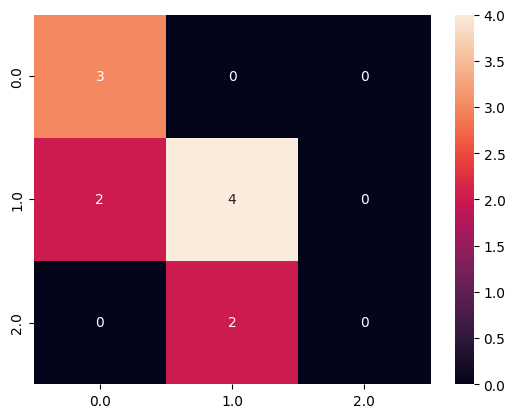

In [50]:
confusion_scores = confusion_matrix(target_test_pol, predicted_rf_fin)
confusion_df = pd.DataFrame(confusion_scores, columns=np.sort(target_test_pol.unique()),
index=np.sort(target_test_pol.unique()))
sns.heatmap(confusion_df, annot=True).plot()

Что тут видно? Модель явно льстит опоссумам - она всегда верно предсказывала класс 0, а в остальных часто ошибалась, но в случае класса 2 ошибка составляла не более одного класса

### Значимость признаков
Давайте посмотрим

In [51]:
feature_importance = list(zip(data_train_pol.columns, perf_model_rf.feature_importances_))
feature_importance_df = pd.DataFrame(feature_importance,
columns=['Признак', 'Значимость'])
print(feature_importance_df)

     Признак  Значимость
0       site    0.008126
1        Pop    0.000000
2        sex    0.000000
3    hdlngth    0.164815
4     skullw    0.152786
5   totlngth    0.089032
6      taill    0.055137
7   footlgth    0.093413
8   earconch    0.112033
9        eye    0.086206
10     chest    0.121853
11     belly    0.116599


Хм... видно что пол и место жительство не оказали влияния (что в целом логично). Наибольшее влияние оказало всё, связанное с головой, на втором месте - длина ступни.
Наверное из этого что-то следует, но более важно что классификатор опоссумов построен и работает:)

## Градиентный бустинг
На последок посмотрим его - подключим, проверим кроссвалидацией и обучим модель

In [52]:
from sklearn.ensemble import HistGradientBoostingClassifier

HGBC= HistGradientBoostingClassifier(max_iter=100)
cv_score_HB=cross_val_score(HGBC,data_train_pol, target_train_pol,cv=10)
print(cv_score_HB.mean())
print(cv_score_HB.std())


0.5222222222222223
0.14948471163415233


In [53]:
model_HGBC=HGBC.fit(data_train_pol, target_train_pol)

predicted_HGBC = model_HGBC.predict(data_test_pol)
results_table = pd.DataFrame(list(zip(predicted_HGBC, target_test_pol)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table)
model_HGBC.score(data_test_pol, target_test_pol)

    Предсказано  На самом деле
0           1.0            0.0
1           1.0            1.0
2           2.0            2.0
3           1.0            2.0
4           0.0            1.0
5           1.0            1.0
6           0.0            0.0
7           1.0            1.0
8           2.0            1.0
9           0.0            0.0
10          2.0            1.0


0.5454545454545454

Вышло чуть хуже, хотя при обучении значения были лучше... Но в этом всё машинное обучение